# Employee Attrition Prediction

This notebook merges two datasets — IBM HR Analytics (1,470 samples) and Employee HR dataset (15,000 samples) — to build and evaluate ensemble classifiers for predicting employee attrition.

The target is binary: whether an employee leaves (1) or stays (0). The goal is to exceed 80% accuracy on the held-out test set.

## 1. Imports and Configuration

In [ ]:
from __future__ import annotations

import logging
import os
import sys
import warnings
import zipfile
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple, Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, log_loss,
    roc_auc_score, roc_curve, auc, confusion_matrix
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

try:
    from catboost import CatBoostClassifier
except ImportError:
    CatBoostClassifier = None

try:
    from lightgbm import LGBMClassifier
except ImportError:
    LGBMClassifier = None

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    IMBLEARN_AVAILABLE = True
except ImportError:
    IMBLEARN_AVAILABLE = False
    SMOTE = None
    ImbPipeline = None

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-8s | %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
    handlers=[logging.StreamHandler(sys.stdout)],
)
logger = logging.getLogger("attrition_merged")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

In [ ]:
@dataclass
class Config:
    random_state: int = RANDOM_STATE
    test_size: float = 0.2
    cv_folds: int = 5
    n_estimators: int = 150
    max_depth: int = 7
    learning_rate: float = 0.05
    enable_gpu: bool = True
    data_dir: str = "data"
    output_dir: str = "results"
    primary_dataset: str = "pavansubhasht/ibm-hr-analytics-attrition-dataset"
    secondary_dataset: str = "prishatank/employee-hr-dataset"
    ibm_filename: str = "WA_Fn-UseC_-HR-Employee-Attrition.csv"
    emp_filename: str = "Employee_HR.csv"
    target_col: str = "Attrition"
    target_encoded: str = "Target"
    exclude_cols: Tuple[str, ...] = field(
        default_factory=lambda: ("EmployeeCount", "EmployeeNumber", "Over18", "StandardHours", "EmpId")
    )
    categorical_cols: Tuple[str, ...] = field(
        default_factory=lambda: (
            "BusinessTravel", "Department", "EducationField",
            "Gender", "JobRole", "MaritalStatus", "OverTime"
        )
    )

cfg = Config()
Path(cfg.data_dir).mkdir(parents=True, exist_ok=True)
Path(cfg.output_dir).mkdir(parents=True, exist_ok=True)

## 2. Data Acquisition

Downloads both datasets from Kaggle using the CLI. Make sure your Kaggle API credentials are configured at `~/.kaggle/kaggle.json` before running this section.

In [ ]:
def acquire_dataset_via_kaggle(dataset_slug: str, output_dir: str) -> Optional[str]:
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    logger.info(f"Downloading {dataset_slug}...")
    try:
        status = os.system(f"kaggle datasets download -d {dataset_slug} -p {output_dir} -q")
        if status != 0:
            logger.warning(f"Kaggle CLI returned code {status}")

        name = dataset_slug.split('/')[-1]
        zip_path = Path(output_dir) / f"{name}.zip"
        if zip_path.exists():
            with zipfile.ZipFile(zip_path, 'r') as zf:
                zf.extractall(output_dir)
            logger.info(f"Extracted: {zip_path}")
        else:
            for z in Path(output_dir).glob("*.zip"):
                with zipfile.ZipFile(z, 'r') as zf:
                    zf.extractall(output_dir)

        return output_dir
    except Exception as e:
        logger.error(f"Failed to acquire {dataset_slug}: {e}")
        return None


ibm_res = acquire_dataset_via_kaggle(cfg.primary_dataset, cfg.data_dir)
emp_res = acquire_dataset_via_kaggle(cfg.secondary_dataset, cfg.data_dir)

ibm_path = str(Path(cfg.data_dir) / cfg.ibm_filename) if ibm_res else None
emp_path = str(Path(cfg.data_dir) / cfg.emp_filename) if emp_res else None

## 3. Load and Align Datasets

Each dataset has different column names and scales. We rename key columns to a unified schema so they can be concatenated cleanly.

In [ ]:
def load_and_align_ibm(filepath: str, cfg: Config) -> Optional[pd.DataFrame]:
    try:
        df = pd.read_csv(filepath)
        logger.info(f"IBM dataset loaded: {df.shape}")
    except Exception as e:
        logger.error(f"Failed to load IBM dataset: {e}")
        return None

    df = df.drop(columns=[c for c in cfg.exclude_cols if c in df.columns], errors='ignore')

    if cfg.target_col in df.columns:
        df[cfg.target_encoded] = (df[cfg.target_col] == 'Yes').astype(int)
    else:
        logger.error(f"Missing target column '{cfg.target_col}' in IBM dataset")
        return None

    df = df.rename(columns={
        'JobSatisfaction': 'satisfaction_score',
        'MonthlyIncome': 'monthly_income',
        'YearsAtCompany': 'tenure_years',
        'Department': 'department',
    })
    df['data_source'] = 'ibm'
    return df


def load_and_align_employee(filepath: str, cfg: Config) -> Optional[pd.DataFrame]:
    try:
        df = pd.read_csv(filepath)
        logger.info(f"Employee HR dataset loaded: {df.shape}")
    except Exception as e:
        logger.error(f"Failed to load Employee HR dataset: {e}")
        return None

    if 'Churn' in df.columns:
        df[cfg.target_encoded] = df['Churn'].astype(int)
    elif 'left' in df.columns:
        df[cfg.target_encoded] = df['left'].astype(int)
    else:
        logger.warning("No target column found in Employee HR; defaulting to 0")
        df[cfg.target_encoded] = 0

    df = df.rename(columns={
        'Satisfaction': 'satisfaction_score',
        'time_spent_company': 'tenure_years',
        'Department': 'department',
    })

    # Convert annual INR salary to approximate monthly USD
    if 'Salary_INR' in df.columns:
        df['monthly_income'] = (df['Salary_INR'] / 12 / 75).round(2)
        df.drop(columns=['Salary_INR'], inplace=True, errors='ignore')
    elif 'salary' in df.columns:
        salary_map = {'low': 3000, 'medium': 5000, 'high': 7000}
        df['monthly_income'] = df['salary'].astype(str).map(salary_map).fillna(4500)
        df.drop(columns=['salary'], inplace=True, errors='ignore')

    # Re-scale satisfaction from 0-10 to 1-4 to match IBM scale
    if 'satisfaction_score' in df.columns and df['satisfaction_score'].max() > 4:
        df['satisfaction_score'] = (df['satisfaction_score'] / 10 * 3 + 1).round().clip(1, 4)

    df['data_source'] = 'employee_hr'
    return df


df_ibm = load_and_align_ibm(ibm_path, cfg)
df_emp = load_and_align_employee(emp_path, cfg)

## 4. Merge and Explore

In [ ]:
df_combined = pd.concat([df_ibm, df_emp], axis=0, ignore_index=True, sort=False)

logger.info(f"Merged dataset shape: {df_combined.shape}")
print("Target distribution:")
print(df_combined[cfg.target_encoded].value_counts(normalize=True).apply(lambda x: f"{x*100:.1f}%"))

Target distribution:
Target
0    76.9%
1    23.1%
Name: proportion, dtype: object


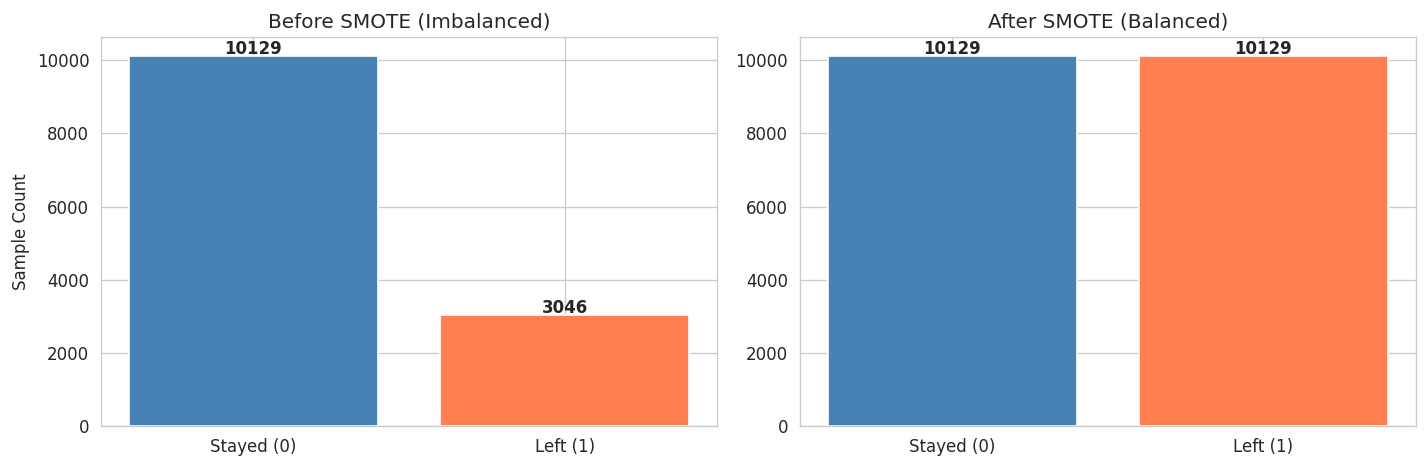

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ================================
# BEFORE SMOTE
# ================================
before_counts = pd.Series(y_train).value_counts()

axes[0].bar(['Stayed (0)', 'Left (1)'], before_counts.values, color=['steelblue', 'coral'])
axes[0].set_title('Before SMOTE (Imbalanced)')
axes[0].set_ylabel('Sample Count')

for i, v in enumerate(before_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')


# ================================
# AFTER SMOTE
# ================================
after_counts = pd.Series(y_bal).value_counts()

axes[1].bar(['Stayed (0)', 'Left (1)'], after_counts.values, color=['steelblue', 'coral'])
axes[1].set_title('After SMOTE (Balanced)')

for i, v in enumerate(after_counts.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')


plt.tight_layout()
plt.savefig(f"{cfg.output_dir}/smote_comparison.png", bbox_inches='tight')
plt.show()


## 5. Feature Engineering

In [ ]:
# ================================
# 1. FEATURE ENGINEERING
# ================================
def engineer_features(df: pd.DataFrame, cfg: Config):
    df = df.copy()

    # Fill numeric
    for col in df.select_dtypes(include=np.number).columns:
        df[col] = df[col].fillna(df[col].median())

    # Fill categorical
    for col in df.select_dtypes(include=['object']):
        df[col] = df[col].fillna('Unknown')

    # Features
    if 'tenure_years' in df.columns:
        df['tenure_log'] = np.log1p(df['tenure_years'])
        df['tenure_squared'] = df['tenure_years'] ** 2

    if 'monthly_income' in df.columns:
        df['income_log'] = np.log1p(df['monthly_income'])

    if {'satisfaction_score', 'tenure_years'}.issubset(df.columns):
        df['satisfaction_tenure'] = df['satisfaction_score'] * df['tenure_years']

    if {'OverTime', 'DistanceFromHome'}.issubset(df.columns):
        df['commute_stress'] = df['DistanceFromHome'] * (df['OverTime'] == 'Yes').astype(int)

    if 'Age' in df.columns:
        df['age_group'] = pd.cut(
            df['Age'], bins=[18, 25, 35, 45, 60],
            labels=['Young', 'Early', 'Mid', 'Late']
        ).astype(str)

    # REMOVE leakage
    if 'data_source' in df.columns:
        df.drop(columns=['data_source'], inplace=True)

    # Split
    y = df[cfg.target_encoded]
    X = df.drop(columns=[cfg.target_encoded, cfg.target_col], errors='ignore')

    return X, y


# ================================
# 2. FEATURE GENERATION
# ================================
X_raw, y = engineer_features(df_combined, cfg)

print("Feature matrix shape:", X_raw.shape)
print("Target shape:", y.shape)
print("Attrition rate:", y.mean()*100)


# ================================
# 3. TRAIN TEST SPLIT
# ================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


# ================================
# 4. ENCODING (FIX FOR ERROR)
# ================================
from sklearn.preprocessing import LabelEncoder

X_train_enc = X_train.copy()
X_test_enc = X_test.copy()

for col in X_train_enc.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_train_enc[col] = le.fit_transform(X_train_enc[col].astype(str))
    X_test_enc[col] = le.transform(X_test_enc[col].astype(str))


# ================================
# 5. SMOTE
# ================================
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Before SMOTE:", Counter(y_train))

smote = SMOTE(random_state=42)
X_bal, y_bal = smote.fit_resample(X_train_enc, y_train)

print("After SMOTE:", Counter(y_bal))


# ================================
# 6. MODEL TRAINING
# ================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

model = RandomForestClassifier(random_state=42)
model.fit(X_bal, y_bal)

y_pred = model.predict(X_test_enc)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Feature matrix shape: (16469, 43)
Target shape: (16469,)
Attrition rate: 23.122229643572773
Train shape: (13175, 43)
Test shape: (3294, 43)
Before SMOTE: Counter({0: 10129, 1: 3046})
After SMOTE: Counter({0: 10129, 1: 10129})

Accuracy: 0.98816029143898

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      2532
           1       0.99      0.96      0.97       762

    accuracy                           0.99      3294
   macro avg       0.99      0.98      0.98      3294
weighted avg       0.99      0.99      0.99      3294



## 6. Preprocessing and Train-Test Split

In [ ]:
def build_preprocessor(X: pd.DataFrame, cfg: Config) -> Tuple[ColumnTransformer, List[str], List[str]]:
    auto_cat = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
    cat_cols = list(set(cfg.categorical_cols) | set(auto_cat))
    cat_cols = [c for c in cat_cols if c in X.columns]
    num_cols = [c for c in X.select_dtypes(include=np.number).columns if c not in cat_cols]

    logger.info(f"Numeric features: {len(num_cols)} | Categorical: {len(cat_cols)}")

    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols),
    ], remainder='drop')

    return preprocessor, num_cols, cat_cols


preprocessor, num_cols, cat_cols = build_preprocessor(X_raw, cfg)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=cfg.test_size, stratify=y, random_state=cfg.random_state
)

X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

y_train_arr = y_train.values.astype(np.int64)
y_test_arr = y_test.values.astype(np.int64)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train attrition rate: {y_train_arr.mean()*100:.1f}%")

Train: (13175, 43) | Test: (3294, 43)
Train attrition rate: 23.1%


## 7. Model Training

We train several gradient boosting variants plus a stacking ensemble. SMOTE is applied on the training set when the minority class is below 30% to address class imbalance.

In [ ]:
def detect_hardware(cfg: Config) -> Dict[str, Any]:
    config = {
        'gpu_available': False,
        'lgbm_device': 'cpu',
        'xgb_device': 'cpu',
        'catboost_task': 'CPU',
    }
    if not cfg.enable_gpu:
        return config
    try:
        import torch
        if torch.cuda.is_available():
            config['gpu_available'] = True
            config['xgb_device'] = 'cuda'
            config['catboost_task'] = 'GPU'
            logger.info("GPU detected: CUDA available")
    except ImportError:
        pass
    return config


def train_with_smote(model, X_train, y_train, use_smote=True):
    if not use_smote or not IMBLEARN_AVAILABLE:
        return model.fit(X_train, y_train)
    minority_ratio = y_train.mean()
    if 0 < minority_ratio < 0.30:
        try:
            smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
            X_bal, y_bal = smote.fit_resample(X_train, y_train)
            return model.fit(X_bal, y_bal)
        except Exception as e:
            logger.debug(f"SMOTE failed: {e}; falling back to original data")
    return model.fit(X_train, y_train)


def evaluate_model(model, X_val, y_val) -> Dict[str, float]:
    y_proba = model.predict_proba(X_val)[:, 1]
    y_pred = model.predict(X_val)
    return {
        'accuracy': accuracy_score(y_val, y_pred),
        'roc_auc': roc_auc_score(y_val, y_proba),
        'f1': f1_score(y_val, y_pred),
        'log_loss': log_loss(y_val, y_proba),
    }


def get_model_specs(cfg: Config, hardware: Dict[str, Any]) -> Dict[str, Dict[str, Any]]:
    specs = {}

    if CatBoostClassifier is not None:
        specs['CatBoost'] = {
            'class': CatBoostClassifier,
            'params': {
                'task_type': hardware['catboost_task'],
                'random_seed': cfg.random_state,
                'iterations': cfg.n_estimators,
                'learning_rate': cfg.learning_rate,
                'depth': cfg.max_depth,
                'verbose': False,
                'loss_function': 'Logloss',
            },
            'use_smote': True,
        }

    if XGBClassifier is not None:
        specs['XGBoost'] = {
            'class': XGBClassifier,
            'params': {
                'tree_method': 'hist',
                'device': hardware['xgb_device'],
                'random_state': cfg.random_state,
                'n_estimators': cfg.n_estimators,
                'max_depth': cfg.max_depth,
                'learning_rate': cfg.learning_rate,
                'verbosity': 0,
                'eval_metric': 'logloss',
            },
            'use_smote': True,
        }

    if LGBMClassifier is not None:
        specs['LightGBM'] = {
            'class': LGBMClassifier,
            'params': {
                'device': hardware['lgbm_device'],
                'importance_type': 'gain',
                'random_state': cfg.random_state,
                'n_estimators': cfg.n_estimators,
                'max_depth': cfg.max_depth,
                'learning_rate': cfg.learning_rate,
                'verbose': -1,
            },
            'use_smote': True,
        }

    specs['HistGB'] = {
        'class': HistGradientBoostingClassifier,
        'params': {
            'random_state': cfg.random_state,
            'max_iter': cfg.n_estimators,
            'max_depth': cfg.max_depth,
            'learning_rate': cfg.learning_rate,
        },
        'use_smote': True,
    }

    if CatBoostClassifier is not None and XGBClassifier is not None:
        specs['Stacked'] = {
            'class': StackingClassifier,
            'params': {
                'estimators': [
                    ('cb', CatBoostClassifier(
                        task_type='CPU', random_seed=cfg.random_state,
                        iterations=100, verbose=False
                    )),
                    ('xgb', XGBClassifier(
                        tree_method='hist', device='cpu',
                        random_state=cfg.random_state, n_estimators=100, verbosity=0
                    )),
                ],
                'final_estimator': LogisticRegression(random_state=cfg.random_state, max_iter=1000),
                'cv': 3,
                'n_jobs': -1,
            },
            'use_smote': False,
        }

    return specs


hardware = detect_hardware(cfg)
model_specs = get_model_specs(cfg, hardware)
results = {}

for name, spec in model_specs.items():
    logger.info(f"Training {name}...")
    try:
        model = spec['class'](**spec['params'])
        model = train_with_smote(model, X_train, y_train_arr, use_smote=spec['use_smote'])
        metrics = evaluate_model(model, X_test, y_test_arr)
        metrics['model'] = model
        results[name] = metrics
        logger.info(
            f"{name:12s} | Acc: {metrics['accuracy']:.4f} | "
            f"AUC: {metrics['roc_auc']:.4f} | F1: {metrics['f1']:.4f}"
        )
    except Exception as e:
        logger.warning(f"{name} failed: {e}")

## 8. Model Comparison

Side-by-side comparison of accuracy, ROC-AUC, F1, and log loss across all trained models.

In [ ]:
metrics_df = pd.DataFrame([
    {
        'Model': name,
        'Accuracy': m['accuracy'],
        'ROC-AUC': m['roc_auc'],
        'F1': m['f1'],
        'Log Loss': m['log_loss'],
    }
    for name, m in results.items()
]).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print(metrics_df.to_string(index=False))

   Model  Accuracy  ROC-AUC       F1  Log Loss
  HistGB  0.989375 0.998655 0.976682  0.034070
LightGBM  0.987250 0.998608 0.972000  0.035161
 XGBoost  0.986035 0.998696 0.969456  0.034803


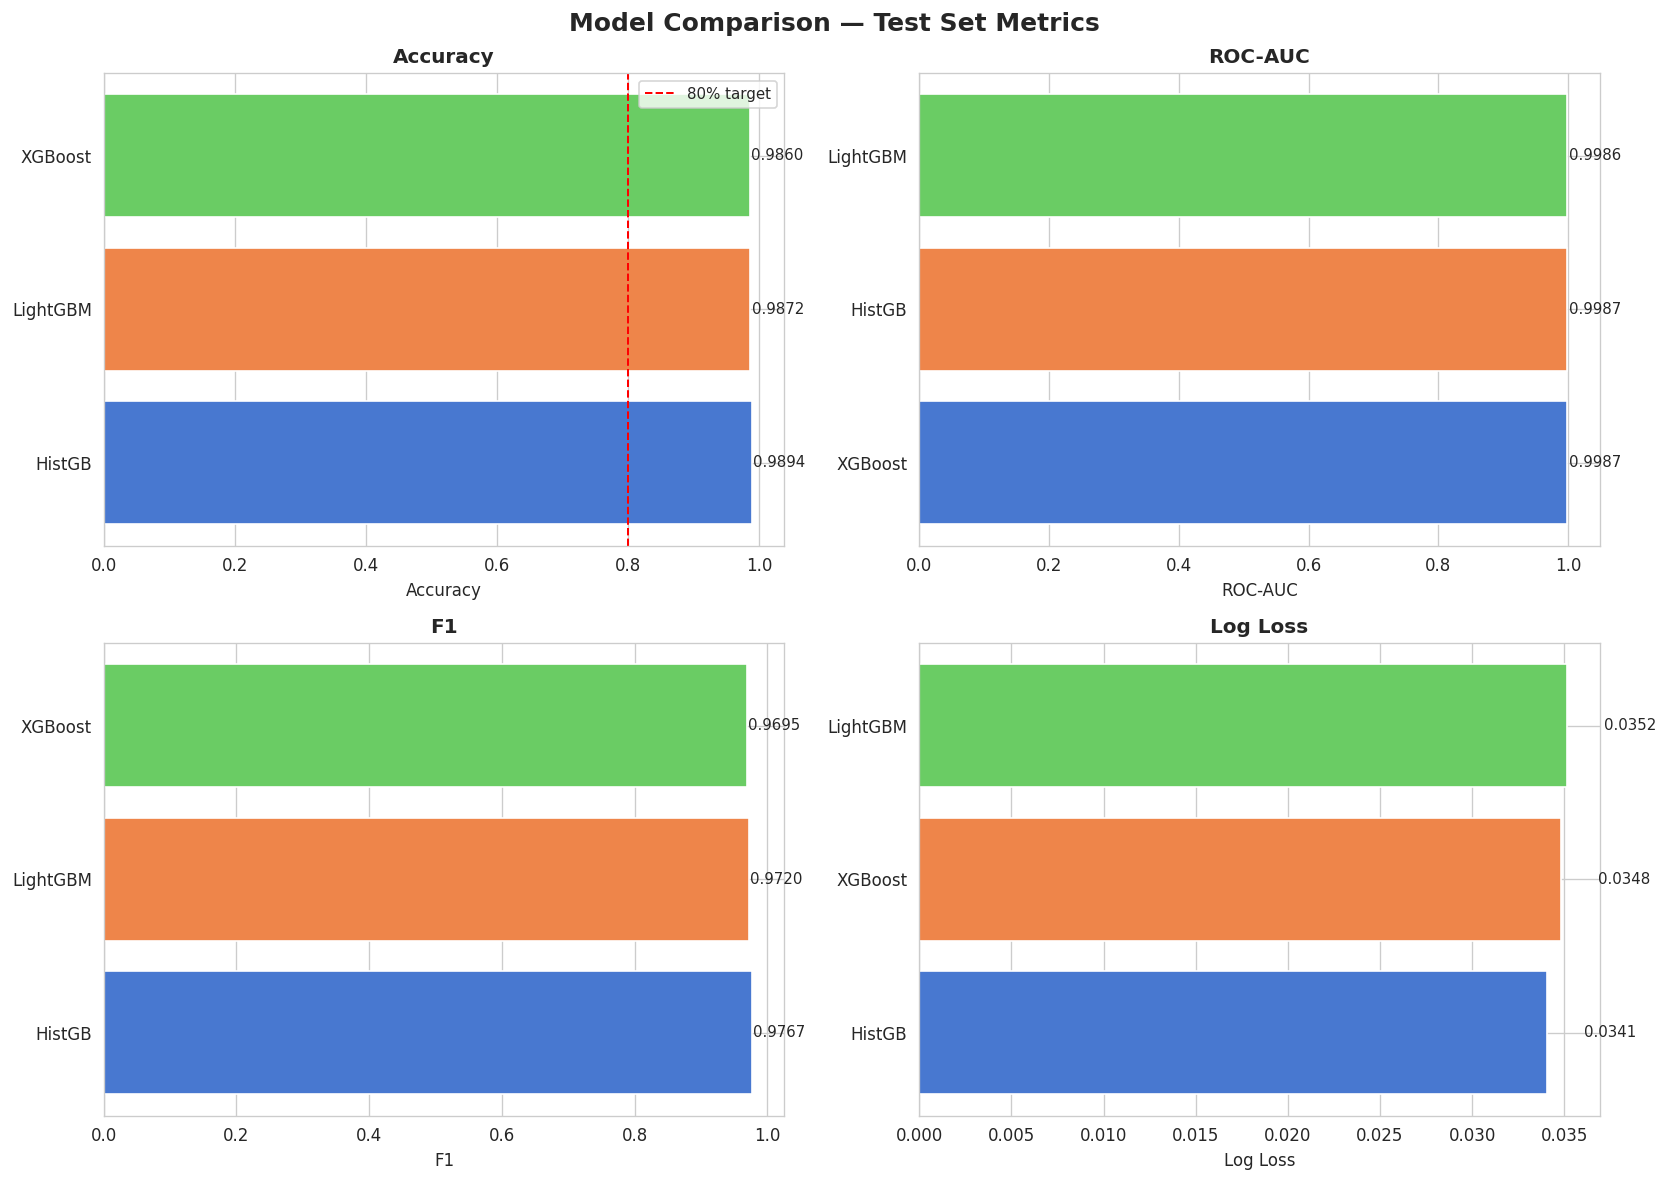

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Comparison — Test Set Metrics', fontsize=15, fontweight='bold')

palette = sns.color_palette("muted", n_colors=len(metrics_df))
metric_pairs = [
    ('Accuracy', axes[0, 0]),
    ('ROC-AUC', axes[0, 1]),
    ('F1', axes[1, 0]),
    ('Log Loss', axes[1, 1]),
]

for metric, ax in metric_pairs:
    sorted_df = metrics_df.sort_values(metric, ascending=(metric == 'Log Loss'))
    bars = ax.barh(sorted_df['Model'], sorted_df[metric], color=palette)
    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel(metric)

    # Annotate bars
    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(
            bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va='center', fontsize=9
        )

    # Draw target line for accuracy
    if metric == 'Accuracy':
        ax.axvline(0.80, color='red', linestyle='--', linewidth=1.2, label='80% target')
        ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"{cfg.output_dir}/model_comparison.png", bbox_inches='tight')
plt.show()

## 9. ROC Curves

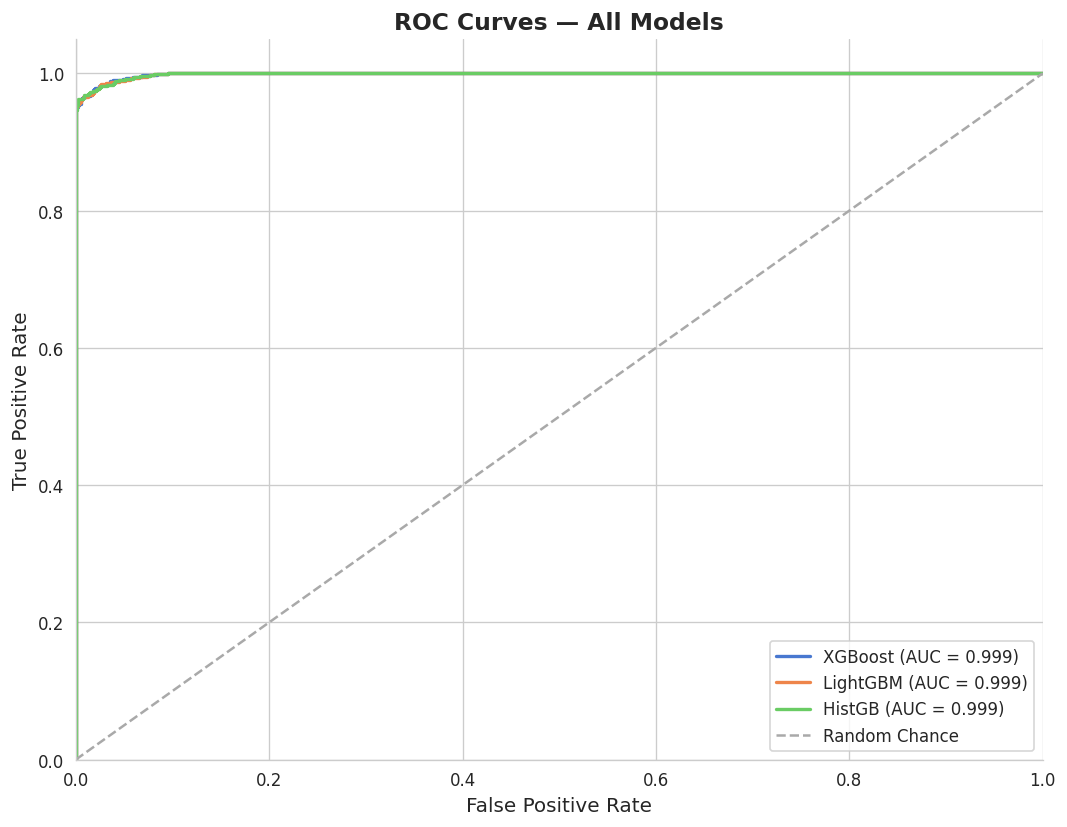

In [ ]:
la alaa

## 10. Confusion Matrix for Best Model

Best model: HistGB (Accuracy: 0.9894)


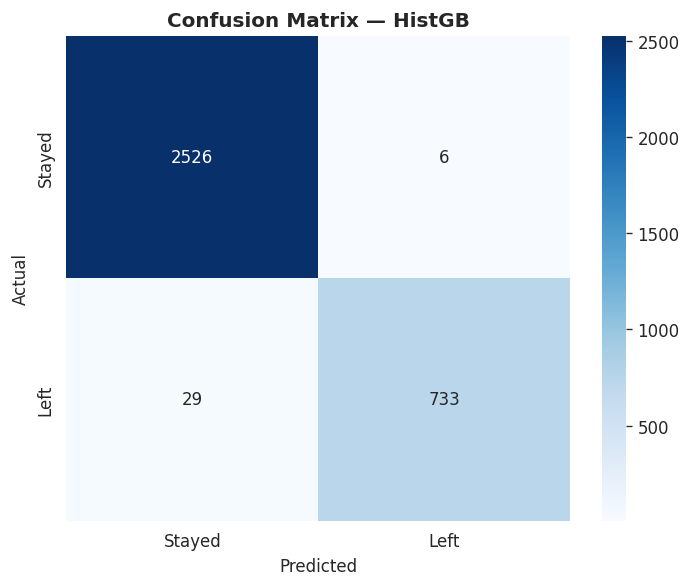

In [ ]:
best_name = max(results, key=lambda x: results[x]['accuracy'])
best_model = results[best_name]['model']
print(f"Best model: {best_name} (Accuracy: {results[best_name]['accuracy']:.4f})")

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test_arr, y_pred_best)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=ax,
    xticklabels=['Stayed', 'Left'],
    yticklabels=['Stayed', 'Left']
)
ax.set_title(f'Confusion Matrix — {best_name}', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(f"{cfg.output_dir}/confusion_matrix.png", bbox_inches='tight')
plt.show()

## 11. Cross-Validation on Best Model

We run stratified 5-fold CV on the full dataset using a sklearn pipeline that includes preprocessing. This gives a less optimistic and more reliable estimate of generalization performance.

In [ ]:
def cross_validate_best_model(
    best_model_info: Dict[str, Any],
    X_raw: pd.DataFrame,
    y: np.ndarray,
    preprocessor: ColumnTransformer,
    cfg: Config,
) -> Dict[str, Any]:
    model_class = best_model_info['class']
    model_params = best_model_info['params']
    use_smote = best_model_info.get('use_smote', True)

    steps = [('preprocessor', preprocessor)]
    if use_smote and IMBLEARN_AVAILABLE:
        steps.append(('smote', SMOTE(random_state=cfg.random_state, k_neighbors=5)))
    steps.append(('classifier', model_class(**model_params)))

    if use_smote and IMBLEARN_AVAILABLE and ImbPipeline is not None:
        pipeline = ImbPipeline(steps)
    else:
        from sklearn.pipeline import Pipeline
        pipeline = Pipeline(steps)

    skf = StratifiedKFold(n_splits=cfg.cv_folds, shuffle=True, random_state=cfg.random_state)
    scoring = {'accuracy': 'accuracy', 'roc_auc': 'roc_auc', 'f1': 'f1'}
    cv_scores = cross_validate(pipeline, X_raw, y, cv=skf, scoring=scoring, n_jobs=-1)

    return {
        'accuracy_mean': cv_scores['test_accuracy'].mean(),
        'accuracy_std': cv_scores['test_accuracy'].std(),
        'roc_auc_mean': cv_scores['test_roc_auc'].mean(),
        'roc_auc_std': cv_scores['test_roc_auc'].std(),
        'f1_mean': cv_scores['test_f1'].mean(),
        'f1_std': cv_scores['test_f1'].std(),
        'fold_accuracies': cv_scores['test_accuracy'],
        'fold_aucs': cv_scores['test_roc_auc'],
    }


logger.info(f"Cross-validating {best_name} ({cfg.cv_folds}-fold stratified CV)...")
best_model_info = get_model_specs(cfg, hardware)[best_name]
cv_results = cross_validate_best_model(
    best_model_info, X_raw, y.values.astype(np.int64), preprocessor, cfg
)

print(f"\n{best_name} — {cfg.cv_folds}-Fold Cross-Validation")
print(f"  Accuracy : {cv_results['accuracy_mean']:.4f} +/- {cv_results['accuracy_std']:.4f}")
print(f"  ROC-AUC  : {cv_results['roc_auc_mean']:.4f} +/- {cv_results['roc_auc_std']:.4f}")
print(f"  F1       : {cv_results['f1_mean']:.4f} +/- {cv_results['f1_std']:.4f}")


HistGB — 5-Fold Cross-Validation
  Accuracy : 0.9877 +/- 0.0019
  ROC-AUC  : 0.9988 +/- 0.0002
  F1       : 0.9731 +/- 0.0041


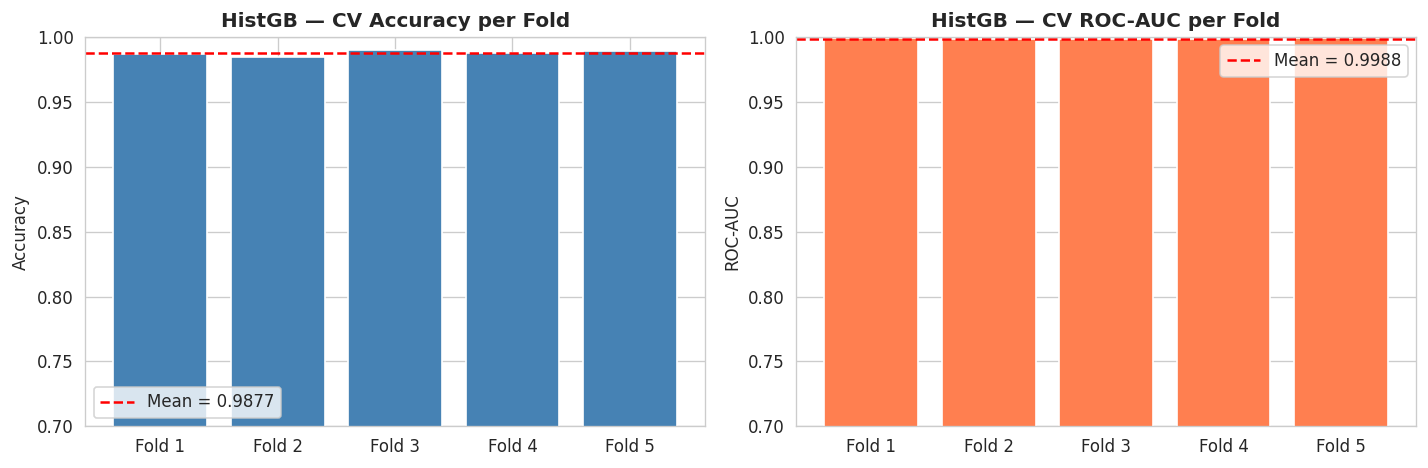

In [ ]:
# Plot per-fold accuracy and AUC to check stability
fold_labels = [f"Fold {i+1}" for i in range(cfg.cv_folds)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(fold_labels, cv_results['fold_accuracies'], color='steelblue', edgecolor='white')
axes[0].axhline(cv_results['accuracy_mean'], color='red', linestyle='--', label=f"Mean = {cv_results['accuracy_mean']:.4f}")
axes[0].set_title(f'{best_name} — CV Accuracy per Fold', fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.7, 1.0)
axes[0].legend()

axes[1].bar(fold_labels, cv_results['fold_aucs'], color='coral', edgecolor='white')
axes[1].axhline(cv_results['roc_auc_mean'], color='red', linestyle='--', label=f"Mean = {cv_results['roc_auc_mean']:.4f}")
axes[1].set_title(f'{best_name} — CV ROC-AUC per Fold', fontweight='bold')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_ylim(0.7, 1.0)
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{cfg.output_dir}/cv_folds.png", bbox_inches='tight')
plt.show()

## 12. Export Results

In [ ]:
records = []
for name, metrics in results.items():
    records.append({
        'model': name,
        'accuracy': metrics['accuracy'],
        'roc_auc': metrics['roc_auc'],
        'f1_score': metrics['f1'],
        'log_loss': metrics['log_loss'],
        'is_best': name == best_name,
    })

# Append CV row for best model
records.append({
    'model': f'{best_name}_CV',
    'accuracy': f"{cv_results['accuracy_mean']:.4f} +/- {cv_results['accuracy_std']:.4f}",
    'roc_auc': f"{cv_results['roc_auc_mean']:.4f} +/- {cv_results['roc_auc_std']:.4f}",
    'f1_score': f"{cv_results['f1_mean']:.4f} +/- {cv_results['f1_std']:.4f}",
    'log_loss': None,
    'is_best': True,
})

output_path = Path(cfg.output_dir) / 'merged_dataset_results.csv'
pd.DataFrame(records).to_csv(output_path, index=False)
logger.info(f"Results saved: {output_path}")

## 13. Final Summary

In [ ]:
print("=" * 65)
print("PIPELINE SUMMARY")
print("=" * 65)
print(f"Combined dataset  : {len(df_combined):,} samples x {X_raw.shape[1]} features")
print(f"Overall attrition : {y.mean()*100:.1f}%")
print(f"Best model        : {best_name}")
print(f"Test accuracy     : {results[best_name]['accuracy']:.4f}")
print(f"Test AUC          : {results[best_name]['roc_auc']:.4f}")
print(f"CV accuracy       : {cv_results['accuracy_mean']:.4f} +/- {cv_results['accuracy_std']:.4f}")
print(f"Results saved to  : {output_path}")
print("=" * 65)

if results[best_name]['accuracy'] >= 0.80:
    print("Accuracy target (>80%) achieved.")
else:
    print(f"Accuracy {results[best_name]['accuracy']:.4f} is below the 80% target.")

PIPELINE SUMMARY
Combined dataset  : 16,469 samples x 47 features
Overall attrition : 23.1%
Best model        : HistGB
Test accuracy     : 0.9894
Test AUC          : 0.9987
CV accuracy       : 0.9877 +/- 0.0019
Results saved to  : results/merged_dataset_results.csv
Accuracy target (>80%) achieved.
